## 1. Load packages

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import sys
import os
from UniProtMapper import ProtMapper
# get project root (two levels up from this notebook)
project_root = os.path.abspath(os.path.join(os.path.dirname('src'), '..'))
# if in notebook:
# project_root = os.path.abspath('..')   # or adjust as needed

if project_root not in sys.path:
    sys.path.insert(0, project_root)
from importlib import reload

/mnt/aiongpfs/users/adhal/micromamba/envs/scrna_target_idf/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## 2. Load scHIIT packages

In [2]:
import src.methods.schiit_method.tf_filters.base_filter as schiit_base
import src.methods.schiit_method.tf_filters.jsd_filter as schiit_main
import src.methods.schiit_method.network.grn_base as schiit_grn
reload(schiit_main)
reload(schiit_grn)

<module 'src.methods.schiit_method.network.grn_base' from '/mnt/scratch/users/adhal/SingleCellUtils/src/methods/schiit_method/network/grn_base.py'>

##  3. Load data method creation for query + reference data 

- reference data: single nuclei data
- query data: seattle AD data

In [3]:
ref_data_path = "/mnt/lscratch/users/adhal/SingleCellUtils/data/scHIIT_ref/ref_nuclei_231125.h5ad"
query_data_path = "/mnt/lscratch/users/adhal/SingleCellUtils/data/scHIIT_query/neuronal/sead/sead_sampled_10K_171125.h5ad"
ref_adata = sc.read_h5ad(ref_data_path)
query_adata = sc.read_h5ad(query_data_path)

## 4. Function to load from h5ad and harmonize the observation columns

- This function is meant for only SEATLLE AD query dataset 
- In case you have a different query dataset, please make sure the ```adata.var_names``` are in GENE NAME and NOT GENEID (ENSEMBL FORMAT)

In [4]:
import src.io.seattle_ad.query_ref_merge as query_ref_merge

In [5]:
query_adata_fixed =  query_ref_merge.fix_query_var_names(query_adata)
# ============================================================================
# USAGE
# ============================================================================
# STEP 1: Merge
merged_adata =  query_ref_merge.merge_query_reference_simple(
    query_adata=query_adata_fixed,
    reference_adata=ref_adata,
    query_cluster_key='Class',  # Options: 'Class', 'Subclass', 'Supertype'
    batch_key='dataset'
)


# STEP 2: Verify
query_ref_merge.verify_merge(merged_adata, batch_key='dataset')


# STEP 4: Save
# merged_adata.write('merged_seattle_tabsap.h5ad')
print("\nMerged data ready for benchmarking! ✓")

# STEP 5: Ready to use with base class
print("\n" + "="*60)
print("USAGE WITH BENCHMARKING METHODS")
print("="*60)
del query_adata_fixed


New var_names (first 5):
Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112'], dtype='object')

Duplicate genes that got suffix:
Index(['NKX3-2', 'NKX2-3', 'H1-3', 'H1-1', 'NKX2-4', 'NKX2-2', 'NKX2-8',
       'NKX2-1', 'ERVK3-1', 'NKX6-2'],
      dtype='object')
MERGING QUERY + REFERENCE (Reference has no metadata)

Step 1: Finding common genes...
  Query genes:     36,412
  Reference genes: 22,298
  Common genes:    20,745

Step 2: Adding metadata...
  Query clusters: 2
  Reference: all labeled as 'background'

Step 3: Preserving query metadata...
  Query-specific columns: 38

Step 4: Aligning gene metadata...

Step 5: Concatenating datasets...

MERGE COMPLETE
Total cells:      181,349
Total genes:      20,745
Query cells:      17,937
Reference cells:  163,412

Query cluster distribution:
  Neuronal: GABAergic: 9,200 cells
  Neuronal: Glutamatergic: 8,737 cells

VERIFICATION

1. Basic structure:
   Total cells: 181,349
   Total genes: 20,745
   Sparse matrix: True

2. Dataset distri

## 3. Start of HIIT pipeline

In [6]:
reload(schiit_main)
reload(schiit_base)

<module 'src.methods.schiit_method.tf_filters.base_filter' from '/mnt/scratch/users/adhal/SingleCellUtils/src/methods/schiit_method/tf_filters/base_filter.py'>

In [7]:
import numpy as np
import gc
from scipy.sparse import csr_matrix, issparse

# Create memory-safe subset (subsample background)
def create_subset(adata, target_ct, max_background=20000):
    target_mask = adata.obs['Class'] == target_ct
    background_mask = adata.obs['Class'] == 'background'
    
    target_idx = np.where(target_mask)[0]
    background_idx = np.where(background_mask)[0]
    
    if len(background_idx) > max_background:
        np.random.seed(42)
        background_idx = np.random.choice(background_idx, max_background, replace=False)
    
    keep_idx = np.concatenate([target_idx, background_idx])
    subset = adata[keep_idx, :].copy()
    
    if not issparse(subset.X):
        subset.X = csr_matrix(subset.X)
    
    return subset

# Run pipeline
reload(schiit_main)
results, stageI_II_tfs = {}, {}

tf_df = pd.read_csv('/mnt/lscratch/users/adhal/data/scrna_target_idf_v2/scrna_target_idf_v2/data/Homo_sapiens_TF.txt', sep='\t')
tf_name_list = tf_df['Symbol'].to_list()

ct = 'Neuronal: GABAergic'
adata_safe = create_subset(merged_adata, ct, max_background=50000)

## 3.1. STAGE I + II for TFs only

In [8]:
method =  'bidirectional_gjsd'
neuro_top_tf = schiit_main.CoreFilterOnlyPipeline(
    adata=adata_safe,  # Use subset
    tf_list=tf_name_list,
    target_cell_type=ct,
    background_cell_type='background',
    cell_type_key='Class',
    chipseq_file=None,
    verbose=True,
    scgx_sig_file='/mnt/lscratch/users/adhal/SingleCellUtils/outputs/scGX/tier1_SEAD/sig_frames/Neuronal: GABAergic_sig_tbl.txt',
    main_filter='high_and_unique',
    jsd_method=method,
    top_n_high=None,
    top_jsd_pc=None,
    top_n_jsd=1000,
    expr_method='scgx',
    identity_top_percent=10.0,  # NEW: top 10% for identity

)

neuro_top_tf.run()
results[method] = neuro_top_tf.results
stageI_II_tfs[method] = neuro_top_tf.results['core_filtered_tfs']

del adata_safe
gc.collect()

  Converting sparse matrix for parallel processing...
INITIALIZED: CoreFilterOnlyPipeline
Target cell type: Neuronal: GABAergic
Target cells: 9200
Total cells: 59200
Input TFs: 1659

RUNNING: CoreFilterOnlyPipeline

[Core Filtering]
  High expression TFs: 465/1659
  Computing bidirectional_gjsd divergence for 465 TFs...


    Parallel bidirectional_gjsd: 100%|██████████| 465/465 [00:00<00:00, 4983.04it/s]


  Directional filtering: 330/465 genes are target-specific
  Top 1000 TFs (score: 0.018)
  Unique expression TFs: 330/465
  Top 5 by bidirectional_gjsd: PEG3(487.93), ZNF709(206.49), DLX1(78.27), ZNF587B(66.31), ZSCAN26(55.60)
Core filtered TFs (high & unique): 330

[Additional Filtering]
  No additional filtering applied
  Final filtered TFs: 330

[Network Construction]
  No network built (baseline uses core filters only)
  Network: 330 nodes, 0 edges

[Identity TF Selection]
  Identity TF selection: 33 TFs
  Identity TFs found: 33

RESULTS SUMMARY

Filtering Cascade:
  Input TFs:        1659
  ├─ High expr:      465
  ├─ Unique expr:    330
  ├─ Core (both):    330
  └─ Final:          330

Network:
  Nodes:             330
  Edges:               0

Identity TFs:
  Found:              33

Runtime: 2.01s


3090

## 3.2. Take a look at the results visually to make sure method is working

In [9]:
# Get full directional DataFrame
df = neuro_top_tf.get_directional_scores_df()

print("\\n=== Directional GJSD Results ===")
print(df.head(10))

# Filter for TARGET-SPECIFIC genes only
target_specific = df[
    (df['signed_specificity'] > 0) &           # Positive direction
    (df['specificity_target'] > 0.65) &        # High confidence
    (df['gjsd_score'] > 1.0)                   # Minimum divergence
].sort_values('signed_specificity', ascending=False)

print(f"\\nTarget-specific genes: {len(target_specific)}")
print(target_specific[['gjsd_score', 'direction', 'specificity_target', 
                       'mean_target', 'mean_other']].head(20))

# Filter for BACKGROUND-SPECIFIC genes
background_specific = df[
    (df['signed_specificity'] < 0) &
    (df['specificity_other'] > 0.65) &
    (df['gjsd_score'] > 1.0)
].sort_values('signed_specificity', ascending=True)

print(f"\\nBackground-specific genes: {len(background_specific)}")

\n=== Directional GJSD Results ===
         gjsd_score    direction  signed_specificity  kl_target_other  \
gene                                                                    
PEG3     487.931687  1951.339257          487.931687      1955.559746   
ZNF709   206.492054   825.582417          206.492054       828.826303   
DLX1      78.269256   312.691954           78.269256       315.463773   
ZNF587B   66.312384   264.864042           66.312384       267.608777   
ZSCAN26   55.602996   222.027143           55.602996       224.651187   
ZNF417    54.592151   217.984342           54.592151       220.556414   
ZNF655    38.056038   151.836581           38.056038       154.417840   
ZNF605    37.814925   150.875652           37.814925       153.305477   
ZFP91     33.746455   134.601951           33.746455       136.980497   
ZNF585A   29.627156   118.125596           29.627156       120.419937   

         kl_other_target  specificity_target  specificity_other  mean_target  \
gene    

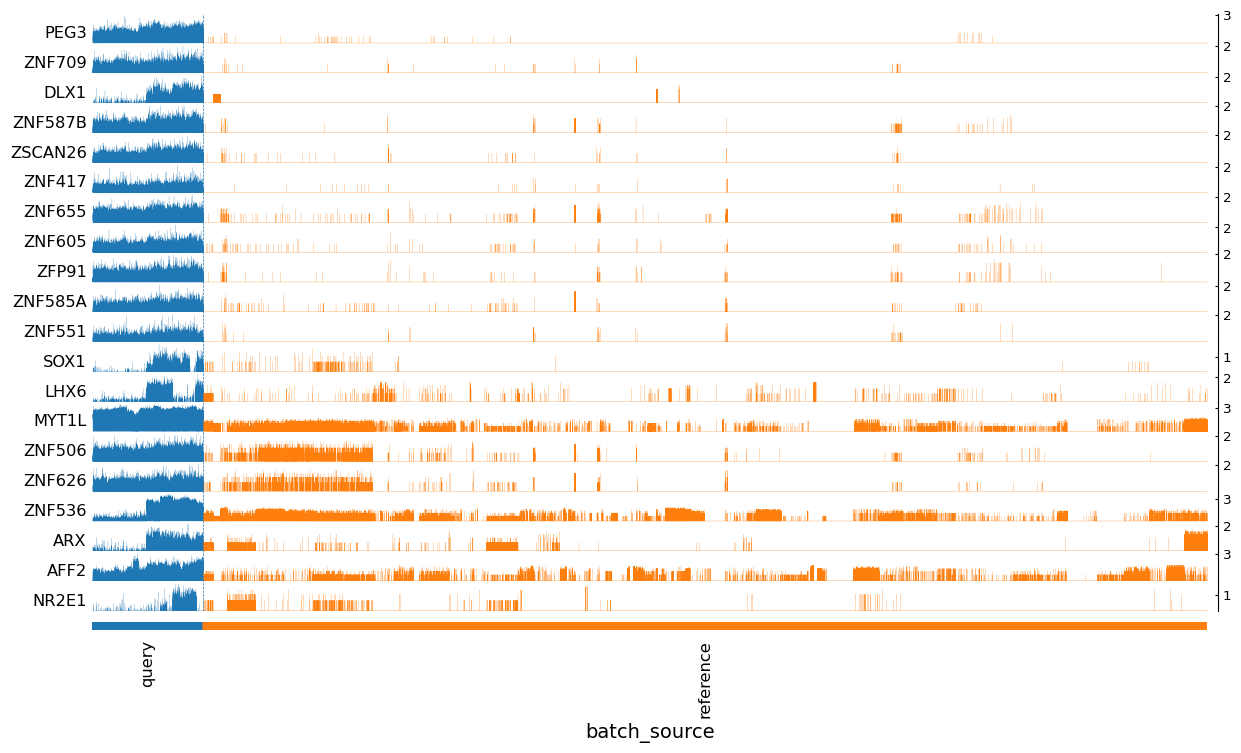

In [10]:
import matplotlib.pyplot as plt
# Set font sizes before plotting
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

ax = sc.pl.tracksplot(
    merged_adata, 
    target_specific.index.values[:20], 
    groupby="batch_source", 
    dendrogram=False, 
    figsize=(15, 8),
    show=False
)
plt.show()

## 5.3. Stage I + II for Genes 

In [11]:
# import numpy as np
# import gc
# from scipy.sparse import csr_matrix, issparse

# # Create memory-safe subset (subsample background)
# def create_subset(adata, target_ct, max_background=20000):
#     target_mask = adata.obs['Class'] == target_ct
#     background_mask = adata.obs['Class'] == 'background'
    
#     target_idx = np.where(target_mask)[0]
#     background_idx = np.where(background_mask)[0]
    
#     if len(background_idx) > max_background:
#         np.random.seed(42)
#         background_idx = np.random.choice(background_idx, max_background, replace=False)
    
#     keep_idx = np.concatenate([target_idx, background_idx])
#     subset = adata[keep_idx, :].copy()
    
#     if not issparse(subset.X):
#         subset.X = csr_matrix(subset.X)
    
#     return subset

# # Run pipeline
# reload(schiit_main)
# results, stageI_II_tfs = {}, {}

# tf_df = pd.read_csv('/mnt/lscratch/users/adhal/data/scrna_target_idf_v2/scrna_target_idf_v2/data/Homo_sapiens_TF.txt', sep='\t')
# tf_name_list = tf_df['Symbol'].to_list()

# ct = 'Neuronal: GABAergic'
# adata_safe = create_subset(merged_adata, ct, max_background=50000)

# results_genes = {}
# stageI_II_genes = {}
# gene_list = list(set(adata_safe.var_names) - set(tf_name_list))
# method =  'bidirectional_gjsd'
# neuro_top_genes = schiit_main.CoreFilterOnlyPipeline(
#     adata=adata_safe,  # Use subset
#     tf_list=gene_list,
#     target_cell_type=ct,
#     background_cell_type='background',
#     cell_type_key='Class',
#     chipseq_file=None,
#     verbose=True,
#     scgx_sig_file='/mnt/lscratch/users/adhal/SingleCellUtils/outputs/scGX/tier1_SEAD/sig_frames/Neuronal: GABAergic_sig_tbl.txt,
#     main_filter='unique_only',
#     jsd_method=method,
#     top_n_high=700,
#     top_jsd_pc=None,
#     top_n_jsd=30,
#     expr_method='scgx',

# )

# neuro_top_genes.run()
# results_genes[method] = neuro_top_genes.results
# stageI_II_genes[method] = neuro_top_genes.results['core_filtered_tfs']

# del adata_safe
# gc.collect()

## 4.0 Run GRN to build transcriptional core

In [12]:
import src.methods.schiit_method.network.grn_base as schiit_grn
reload(schiit_grn)

<module 'src.methods.schiit_method.network.grn_base' from '/mnt/scratch/users/adhal/SingleCellUtils/src/methods/schiit_method/network/grn_base.py'>

In [13]:
chip_seq_file = '/mnt/lscratch/users/adhal/scrna_target_idf_v3/data/from_martin/Chip_removed_overlapped_peaks.tsv'


stage3_results = schiit_grn.run_stage_iii(
    tf_results=results['bidirectional_gjsd'],
    gene_results=results['bidirectional_gjsd'],
    chipseq_file=chip_seq_file,
    selection_method='largest',
    min_scc_size=2,
    verbose=True,
    connecting_top_percent=100
)
# Uses: default 1% for connecting TFs



STAGE III: CORE TF IDENTIFICATION

STEP 1: LOAD LITERATURE NETWORK

Loading ChIP-seq: /mnt/lscratch/users/adhal/scrna_target_idf_v3/data/from_martin/Chip_removed_overlapped_peaks.tsv
  ChIP-seq edges: 6844416

Loading CollecTRI...
  CollecTRI edges: 21699

✓ Literature network: 2365733 edges

=== Identifying Connecting TFs ===
  Unique TFs: 33
  Non-unique TFs to evaluate: 432
  Pre-filtered to top 100% = 432 non-unique TFs by score
  Found 128 connecting TFs (after connectivity check)

  Example connections (first 3):
    ZNF92:
      Sources: ['CTCF', 'MITF', 'GABPA']
      Targets: ['TFB1M', 'TEAD1']
    IKZF5:
      Sources: ['CTCF', 'MITF', 'GABPA']
      Targets: ['DNAJC2', 'THAP6', 'GABPA']
    ARID2:
      Sources: ['MITF', 'CTCF', 'ZNF341']
      Targets: ['ZBTB18', 'ZNF141', 'E2F3']

=== Building Regulatory Network ===
  Core set size: 161
    - Unique TFs: 33
    - Connecting TFs: 128
  Network statistics:
    Nodes: 161
    Edges: 5827
    Density: 0.2262
    Weakly connec

## Plotting TF core network

In [14]:
import src.io.plotting_utils as putils

✓ Network saved to: core_network.png


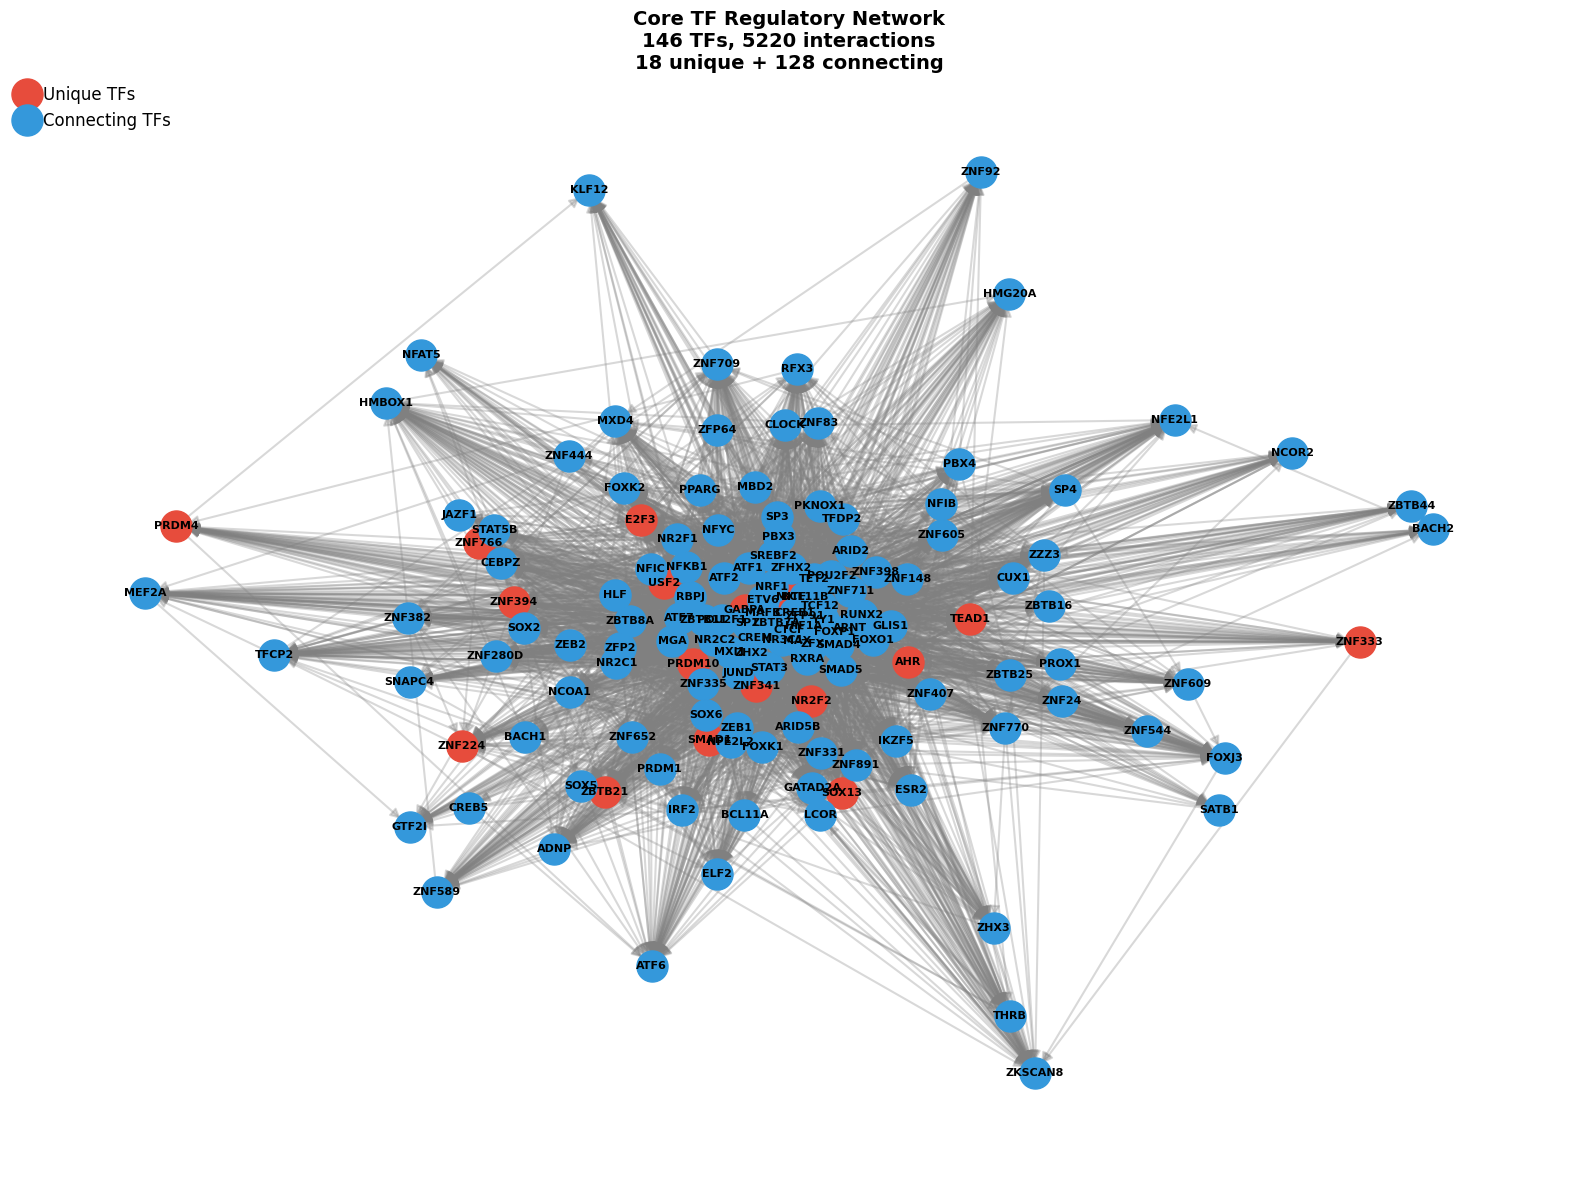

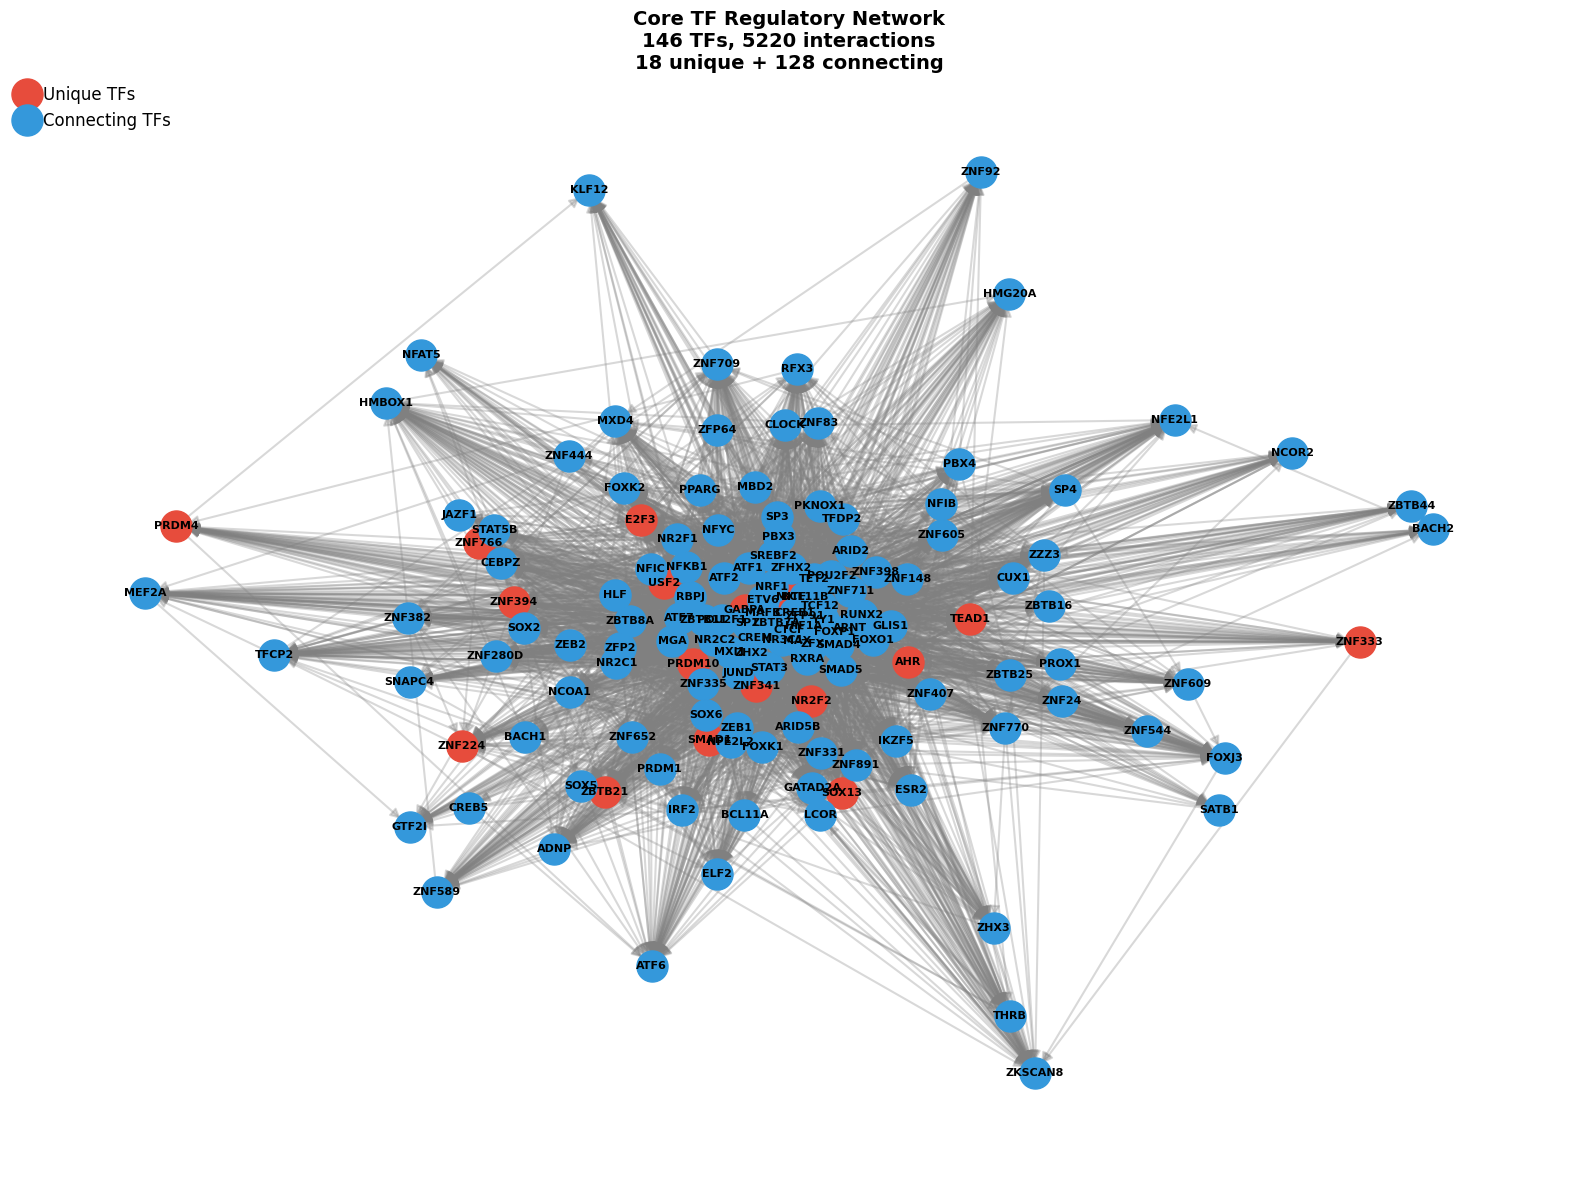

In [15]:
putils.plot_core_network(stage3_results)